In [66]:
import math
from typing import Optional, Tuple, Union

import numpy as np
import torch
import torch.utils.checkpoint
from torch import nn
from torch.nn import CrossEntropyLoss
import matplotlib.pyplot as plt

In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['https_proxy'] = 'http://172.23.31.125:8888'

In [8]:
from transformers.models.whisper.modeling_whisper import WhisperPreTrainedModel,WhisperEncoder
from transformers.utils import (
    add_start_docstrings,
    add_start_docstrings_to_model_forward,
    is_flash_attn_2_available,
    is_flash_attn_greater_or_equal_2_10,
    logging,
    replace_return_docstrings,
)
from transformers.models.whisper.configuration_whisper import WhisperConfig
from transformers.models.whisper.generation_whisper import WhisperGenerationMixin
from transformers.modeling_outputs import (
    BaseModelOutput,
    BaseModelOutputWithPastAndCrossAttentions,
    CausalLMOutputWithCrossAttentions,
    Seq2SeqLMOutput,
    Seq2SeqModelOutput,
    SequenceClassifierOutput,
)

In [4]:
_HIDDEN_STATES_START_POSITION = 1

_CONFIG_FOR_DOC = "WhisperConfig"
_CHECKPOINT_FOR_DOC = "openai/whisper-tiny"
WHISPER_ENCODER_INPUTS_DOCSTRING = r"""
    Args:
        input_features (`torch.FloatTensor` of shape `(batch_size, feature_size, sequence_length)`):
            Float values mel features extracted from the raw speech waveform. Raw speech waveform can be obtained by
            loading a `.flac` or `.wav` audio file into an array of type `List[float]` or a `numpy.ndarray`, *e.g.* via
            the soundfile library (`pip install soundfile`). To prepare the array into `input_features`, the
            [`AutoFeatureExtractor`] should be used for extracting the mel features, padding and conversion into a
            tensor of type `torch.FloatTensor`. See [`~WhisperFeatureExtractor.__call__`]
        head_mask (`torch.Tensor` of shape `(encoder_layers, encoder_attention_heads)`, *optional*):
            Mask to nullify selected heads of the attention modules in the encoder. Mask values selected in `[0, 1]`:

            - 1 indicates the head is **not masked**,
            - 0 indicates the head is **masked**.
        encoder_outputs (`tuple(tuple(torch.FloatTensor)`, *optional*):
            Tuple consists of (`last_hidden_state`, *optional*: `hidden_states`, *optional*: `attentions`)
            `last_hidden_state` of shape `(batch_size, sequence_length, hidden_size)`, *optional*) is a sequence of
            hidden-states at the output of the last layer of the encoder.
        output_attentions (`bool`, *optional*):
            Whether or not to return the attentions tensors of all attention layers. See `attentions` under returned
            tensors for more detail.
        output_hidden_states (`bool`, *optional*):
            Whether or not to return the hidden states of all layers. See `hidden_states` under returned tensors for
            more detail.
        return_dict (`bool`, *optional*):
            Whether or not to return a [`~utils.ModelOutput`] instead of a plain tuple.
"""

In [5]:
class WhisperForAudioClassification(WhisperPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)

        self.encoder = WhisperEncoder(config)
        num_layers = config.num_hidden_layers + 1  # transformer layers + input embeddings
        if config.use_weighted_layer_sum:
            self.layer_weights = nn.Parameter(torch.ones(num_layers) / num_layers)
        self.projector = nn.Linear(config.hidden_size, config.classifier_proj_size)
        self.classifier = nn.Linear(config.classifier_proj_size, config.num_labels)

        # Initialize weights and apply final processing
        self.post_init()

    def freeze_encoder(self):
        """
        Calling this function will disable the gradient computation for the Whisper encoder so that its parameters will
        not be updated during training. Only the projection layers and classification head will be updated.
        """
        self.encoder._freeze_parameters()

    def get_input_embeddings(self) -> nn.Module:
        return self.encoder.get_input_embeddings()

    def set_input_embeddings(self, value: nn.Module):
        self.encoder.set_input_embeddings(value)

    @add_start_docstrings_to_model_forward(WHISPER_ENCODER_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=SequenceClassifierOutput, config_class=_CONFIG_FOR_DOC)
    def forward(
        self,
        input_features: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_outputs: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        labels: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1` a classification loss is computed (Cross-Entropy).

        Returns:

        Example:

        ```python
        >>> import torch
        >>> from transformers import AutoFeatureExtractor, WhisperForAudioClassification
        >>> from datasets import load_dataset

        >>> feature_extractor = AutoFeatureExtractor.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")
        >>> model = WhisperForAudioClassification.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")

        >>> ds = load_dataset("google/fleurs", "all", split="validation", streaming=True)
        >>> sample = next(iter(ds))

        >>> inputs = feature_extractor(
        ...     sample["audio"]["array"], sampling_rate=sample["audio"]["sampling_rate"], return_tensors="pt"
        ... )
        >>> input_features = inputs.input_features

        >>> with torch.no_grad():
        ...     logits = model(input_features).logits

        >>> predicted_class_ids = torch.argmax(logits).item()
        >>> predicted_label = model.config.id2label[predicted_class_ids]
        >>> predicted_label
        'Afrikaans'
        ```"""

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        if self.config.use_weighted_layer_sum:
            output_hidden_states = True
        elif output_hidden_states is None:
            output_hidden_states = self.config.output_hidden_states

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        if encoder_outputs is None:
            encoder_outputs = self.encoder(
                input_features,
                head_mask=head_mask,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
            )

        if self.config.use_weighted_layer_sum:
            hidden_states = encoder_outputs[_HIDDEN_STATES_START_POSITION]
            hidden_states = torch.stack(hidden_states, dim=1)
            norm_weights = nn.functional.softmax(self.layer_weights, dim=-1)
            hidden_states = (hidden_states * norm_weights.view(-1, 1, 1)).sum(dim=1)
        else:
            hidden_states = encoder_outputs[0]

        hidden_states = self.projector(hidden_states)
        pooled_output = hidden_states.mean(dim=1)

        logits = self.classifier(pooled_output)

        loss = None

        if labels is not None:
            loss_fct = CrossEntropyLoss()
            # move labels to correct device to enable PP
            labels = labels.to(logits.device)
            loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + encoder_outputs[1:]
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
        )

In [12]:
class WhisperForEmbeddings(WhisperPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)

        self.encoder = WhisperEncoder(config)
        num_layers = config.num_hidden_layers + 1  # transformer layers + input embeddings
        if config.use_weighted_layer_sum:
            self.layer_weights = nn.Parameter(torch.ones(num_layers) / num_layers)
            
        self.projector = nn.Linear(config.hidden_size, config.proj_size)
        # self.classifier = nn.Linear(config.classifier_proj_size, config.num_labels)

        # Initialize weights and apply final processing
        self.post_init()

    def freeze_encoder(self):
        """
        Calling this function will disable the gradient computation for the Whisper encoder so that its parameters will
        not be updated during training. Only the projection layers and classification head will be updated.
        """
        self.encoder._freeze_parameters()

    def get_input_embeddings(self) -> nn.Module:
        return self.encoder.get_input_embeddings()

    def set_input_embeddings(self, value: nn.Module):
        self.encoder.set_input_embeddings(value)

    @add_start_docstrings_to_model_forward(WHISPER_ENCODER_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=SequenceClassifierOutput, config_class=_CONFIG_FOR_DOC)
    def forward(
        self,
        input_features: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_outputs: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        labels: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1` a classification loss is computed (Cross-Entropy).

        Returns:

        Example:

        ```python
        >>> import torch
        >>> from transformers import AutoFeatureExtractor, WhisperForAudioClassification
        >>> from datasets import load_dataset

        >>> feature_extractor = AutoFeatureExtractor.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")
        >>> model = WhisperForAudioClassification.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")

        >>> ds = load_dataset("google/fleurs", "all", split="validation", streaming=True)
        >>> sample = next(iter(ds))

        >>> inputs = feature_extractor(
        ...     sample["audio"]["array"], sampling_rate=sample["audio"]["sampling_rate"], return_tensors="pt"
        ... )
        >>> input_features = inputs.input_features

        >>> with torch.no_grad():
        ...     embeddings = model(input_features).logits

        ```"""

        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        if self.config.use_weighted_layer_sum:
            output_hidden_states = True
        elif output_hidden_states is None:
            output_hidden_states = self.config.output_hidden_states

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        if encoder_outputs is None:
            encoder_outputs = self.encoder(
                input_features,
                head_mask=head_mask,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
            )

        if self.config.use_weighted_layer_sum:
            hidden_states = encoder_outputs[_HIDDEN_STATES_START_POSITION]
            hidden_states = torch.stack(hidden_states, dim=1)
            norm_weights = nn.functional.softmax(self.layer_weights, dim=-1)
            hidden_states = (hidden_states * norm_weights.view(-1, 1, 1)).sum(dim=1)
        else:
            hidden_states = encoder_outputs[0]

        hidden_states = self.projector(hidden_states)
        pooled_output = hidden_states.mean(dim=1)

        return {'audio_feat': pooled_output}

In [14]:
from transformers import AutoFeatureExtractor, WhisperModel
from datasets import load_dataset

In [17]:
model = WhisperModel.from_pretrained("openai/whisper-tiny")

In [ ]:
model.decoder

In [30]:
tokenize = AutoFeatureExtractor.from_pretrained("openai/whisper-tiny")

In [ ]:
tokenize.save_pretrained('./whisper-tiny-encoder')

In [18]:
encoder = model.encoder

In [25]:
type(encoder.config)

transformers.models.whisper.configuration_whisper.WhisperConfig

In [23]:
encoder.config.save_pretrained('./whisper-tiny-encoder')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50358, 50359, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}


In [88]:
model = WhisperModel.from_pretrained("openai/whisper-base")
encoder = model.encoder

encoder.config.save_pretrained('./whisper-base-encoder')
encoder.save_pretrained('./whisper-base-encoder')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50358, 50359, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}
Some non-default generation parameters are set in the model config. These should go into a G

In [26]:
encoder.save_pretrained('./whisper-tiny-encoder')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50358, 50359, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}


WhisperEncoder.from_pretrained("openai/whisper-tiny")

In [ ]:
WhisperEncoder.from_pretrained("./whisper-tiny-encoder")

In [ ]:
feature_extractor = AutoFeatureExtractor.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")
model = WhisperForAudioClassification.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")

In [11]:
ds = load_dataset("google/fleurs", "all", split="validation", streaming=True)
sample = next(iter(ds))

inputs = feature_extractor(
    sample["audio"]["array"], sampling_rate=sample["audio"]["sampling_rate"], return_tensors="pt"
)
input_features = inputs.input_features

with torch.no_grad():
    logits = model(input_features).logits

predicted_class_ids = torch.argmax(logits).item()
predicted_label = model.config.id2label[predicted_class_ids]
predicted_label

/home/yangwenhao/anaconda3/envs/py38_torch12/lib/python3.8/site-packages/datasets/load.py:1486: FutureWarning: The repository for google/fleurs contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/google/fleurs
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


'Afrikaans'

In [32]:
inputs['input_features'].shape

torch.Size([1, 80, 3000])

In [46]:

inputs = feature_extractor(
    [sample["audio"]["array"][:48000], sample["audio"]["array"][48000:],sample["audio"]["array"],], sampling_rate=sample["audio"]["sampling_rate"], return_tensors="pt"
)

In [45]:
feature_extractor.return_attention_mask = True

In [42]:
inputs['input_features'].shape

torch.Size([3, 80, 3000])

In [37]:
sample["audio"]["array"].shape

(218880,)

In [79]:
output = model.encoder(inputs['input_features'], 
                       attention_mask=inputs['attention_mask'], 
                       output_hidden_states=True,)

In [82]:
for p in output.hidden_states:
    print(p.shape)

torch.Size([3, 1500, 384])
torch.Size([3, 1500, 384])
torch.Size([3, 1500, 384])
torch.Size([3, 1500, 384])
torch.Size([3, 1500, 384])


In [83]:
480000 / 1500

320.0

In [77]:
inputs['attention_mask'].shape

torch.Size([3, 480000])

In [62]:
for p in output.attentions:
    print(p.shape)

torch.Size([3, 6, 1500, 1500])
torch.Size([3, 6, 1500, 1500])
torch.Size([3, 6, 1500, 1500])
torch.Size([3, 6, 1500, 1500])


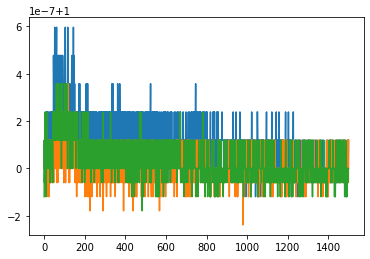

In [75]:
plt.plot(output.attentions[0][0].detach().mean(0).sum(1).numpy())
plt.plot(output.attentions[1][0].detach().mean(0).sum(1).numpy())
plt.plot(output.attentions[2][0].detach().mean(0).sum(1).numpy())

In [55]:
output.last_hidden_state.shape

torch.Size([3, 1500, 384])

In [56]:
inputs['attention_mask'].shape

torch.Size([3, 480000])

In [64]:
output.last_hidden_state.shape

torch.Size([3, 1500, 384])

In [89]:
# import torch
# from transformers import AutoFeatureExtractor, WhisperModel
# from datasets import load_dataset

model = WhisperModel.from_pretrained("openai/whisper-base")
feature_extractor = AutoFeatureExtractor.from_pretrained("openai/whisper-base")
ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
inputs = feature_extractor(ds[0]["audio"]["array"], return_tensors="pt")
input_features = inputs.input_features
decoder_input_ids = torch.tensor([[1, 1]]) * model.config.decoder_start_token_id
output = model(input_features, decoder_input_ids=decoder_input_ids) #.last_hidden_state
list(last_hidden_state.shape)

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

It is strongly recommended to pass the `sampling_rate` argument to this function. Failing to do so can result in silent errors that might be hard to debug.


[1, 2, 512]

In [91]:
input_features

torch.Size([1, 80, 3000])

In [101]:
decoder_input_ids = torch.tensor([[1,]]) * model.config.decoder_start_token_id

output = model(input_features, decoder_input_ids=decoder_input_ids, output_hidden_states=True) #.last_hidden_state


In [97]:
output.keys()

odict_keys(['last_hidden_state', 'past_key_values', 'decoder_hidden_states', 'encoder_last_hidden_state', 'encoder_hidden_states'])

In [99]:
for p in output['decoder_hidden_states']:
    print(p.shape)

torch.Size([1, 2, 512])
torch.Size([1, 2, 512])
torch.Size([1, 2, 512])
torch.Size([1, 2, 512])
torch.Size([1, 2, 512])
torch.Size([1, 2, 512])
torch.Size([1, 2, 512])


In [102]:
decoder_input_ids.shape

torch.Size([1, 1])

In [104]:
output.last_hidden_state.shape

torch.Size([1, 1, 512])